## Is there a relation between the number of years they played and the amount of hits they had during those years? 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy

In [2]:
hitter_data = pd.read_csv("Hitters.csv.xls")

In [3]:
hitter_data

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [4]:
hitter_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

In [42]:
# finding the range

In [ ]:
data = 

In [5]:
years = hitter_data["Years"]
hits = hitter_data["Hits"]

In [6]:
corr = scipy.stats.pearsonr(hits, years)
print(corr)

correlation_score = corr[0]
print("The Correlation Score is:", correlation_score)
# Correlation score of Hits to Years Played

PearsonRResult(statistic=np.float64(0.04476655694238094), pvalue=np.float64(0.42337218615922584))
The Correlation Score is: 0.04476655694238094


In [7]:
linear_model = scipy.stats.linregress(years, hits)

print(linear_model)

LinregressResult(slope=np.float64(0.4221644299516348), intercept=np.float64(97.88221074970787), rvalue=np.float64(0.04476655694238093), pvalue=np.float64(0.42337218615922645), stderr=np.float64(0.5266442494600938), intercept_stderr=np.float64(4.698823469759971))


In [8]:
slope = linear_model[0]
print(slope)

0.4221644299516348


In [9]:
y_intercept = linear_model.intercept

In [10]:
linear_fit = slope*years+y_intercept

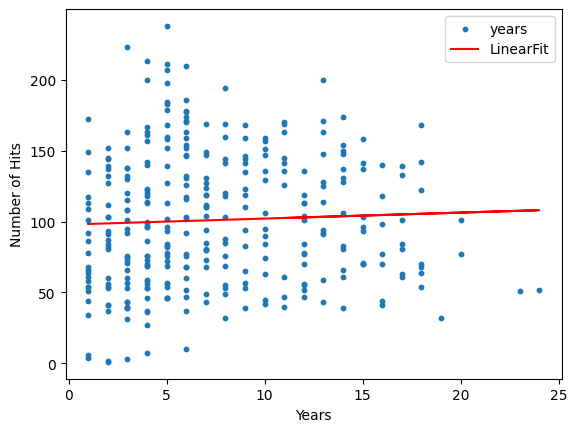

In [11]:
plt.scatter(years, hits, s=10,label="years")
plt.plot(years, linear_fit, color="red", label=("LinearFit"))
plt.xlabel("Years")
plt.ylabel("Number of Hits")
plt.legend()

In [12]:
# I am using machine learning now

In [13]:
hitter_data = hitter_data.drop(columns=["NewLeague"])

In [14]:
hitter_data = hitter_data.drop(columns=["League"])

In [15]:
hitter_data = hitter_data.drop(columns=["Division"])

In [16]:
hitter_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AtBat    322 non-null    int64  
 1   Hits     322 non-null    int64  
 2   HmRun    322 non-null    int64  
 3   Runs     322 non-null    int64  
 4   RBI      322 non-null    int64  
 5   Walks    322 non-null    int64  
 6   Years    322 non-null    int64  
 7   CAtBat   322 non-null    int64  
 8   CHits    322 non-null    int64  
 9   CHmRun   322 non-null    int64  
 10  CRuns    322 non-null    int64  
 11  CRBI     322 non-null    int64  
 12  CWalks   322 non-null    int64  
 13  PutOuts  322 non-null    int64  
 14  Assists  322 non-null    int64  
 15  Errors   322 non-null    int64  
 16  Salary   263 non-null    float64
dtypes: float64(1), int64(16)
memory usage: 42.9 KB


In [17]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

In [19]:
y = hitter_data["Years"]
X = hitter_data["Hits"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)

In [20]:
print(len(X_train))
print(len(X)*0.8)

257
257.6


In [21]:
X = hitter_data[["Hits", "Walks"]]
y = hitter_data["Years"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [22]:
print(len(y_train))
print(len(hitter_data)*0.80)

257
257.6


In [23]:
print(X_train)

     Hits  Walks
33    168     56
275   112     35
82    238     53
127   120     31
271   163     62
..    ...    ...
123    84     47
192   141     37
248   160     89
320   144     78
262    68     61

[257 rows x 2 columns]


In [24]:
classifier = KNeighborsClassifier(n_neighbors=3)
# This tells the computer to find the nearest neighbors of the data columns that we chose as the X and y data/
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [25]:
prediction = classifier.predict(X_test)

In [26]:
print(prediction[0:100])

[11  1  3  1  2  2  3  5  1  2  1 12  3  4  2  1  1  3  5  5 11  3  6  4
  5  1 12  6  1  2  3  4 10  1  2  3  5  4  2 12  6  4  1  1  1  4  1  1
 11  3  6  2  5  8  6  1  4  5  2  1  1  6  5  1  3]


In [27]:
accuracy = accuracy_score(y_test, prediction)
# Multiply by 100 when printed to make a percent
print(accuracy*100)

10.76923076923077


In [28]:
# this is a very low accuracy score at 9% accuracy

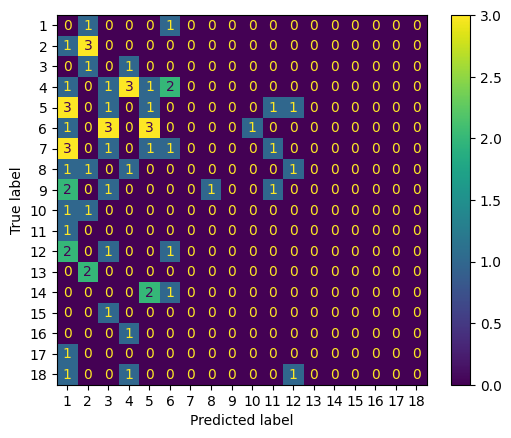

In [29]:
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

In [30]:
# As you can see, the confusion matrix is very "Confusing" if you could say to look at. I am going to make a seperate data set so I 
# can be able to read it better.
# Now lets try and improve the model.

In [31]:
hitter_data_corr = hitter_data.corr(numeric_only=True)
hitter_data_corr

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
AtBat,1.000000,0.967939,0.592198,0.913060,0.820539,0.669845,0.047372,0.235526,0.252717,0.236659,0.266534,0.244053,0.166123,0.317550,0.353824,0.352117,0.394771
Hits,0.967939,1.000000,0.562158,0.922187,0.811073,0.641211,0.044767,0.227565,0.255815,0.202712,0.261787,0.232005,0.151818,0.310673,0.320455,0.310038,0.438675
HmRun,0.592198,0.562158,1.000000,0.650988,0.855122,0.481014,0.116318,0.221882,0.220627,0.493227,0.262361,0.351979,0.233154,0.282923,-0.106329,0.039318,0.343028
Runs,0.913060,0.922187,0.650988,1.000000,0.798206,0.732213,0.004541,0.186497,0.204830,0.227913,0.250556,0.205976,0.182168,0.279347,0.220567,0.240475,0.419859
RBI,0.820539,0.811073,0.855122,0.798206,1.000000,0.615997,0.146168,0.294688,0.308201,0.441771,0.323285,0.393184,0.250914,0.343186,0.106591,0.193370,0.449457
Walks,0.669845,0.641211,0.481014,0.732213,0.615997,1.000000,0.136475,0.277175,0.280671,0.332473,0.338478,0.308631,0.424507,0.299515,0.149656,0.129382,0.443867
Years,0.047372,0.044767,0.116318,0.004541,0.146168,0.136475,1.000000,0.920289,0.903631,0.726872,0.882877,0.868812,0.838533,-0.004684,-0.080638,-0.162140,0.400657
CAtBat,0.235526,0.227565,0.221882,0.186497,0.294688,0.277175,0.920289,1.000000,0.995063,0.798836,0.983345,0.949219,0.906501,0.062283,0.002038,-0.066922,0.526135
CHits,0.252717,0.255815,0.220627,0.204830,0.308201,0.280671,0.903631,0.995063,1.000000,0.783306,0.984609,0.945141,0.890954,0.076547,-0.002523,-0.062756,0.548910
CHmRun,0.236659,0.202712,0.493227,0.227913,0.441771,0.332473,0.726872,0.798836,0.783306,1.000000,0.820243,0.929484,0.799983,0.112724,-0.158511,-0.138115,0.524931


([<matplotlib.axis.YTick at 0x117eefe30>,
 [Text(0, 0, 'AtBat'),
  Text(0, 1, 'Hits'),
  Text(0, 2, 'HmRun'),
  Text(0, 3, 'Runs'),
  Text(0, 4, 'RBI'),
  Text(0, 5, 'Walks'),
  Text(0, 6, 'Years'),
  Text(0, 7, 'CAtBat'),
  Text(0, 8, 'CHits'),
  Text(0, 9, 'CHmRun'),
  Text(0, 10, 'CRuns'),
  Text(0, 11, 'CRBI'),
  Text(0, 12, 'CWalks'),
  Text(0, 13, 'PutOuts'),
  Text(0, 14, 'Assists'),
  Text(0, 15, 'Errors'),
  Text(0, 16, 'Salary')])

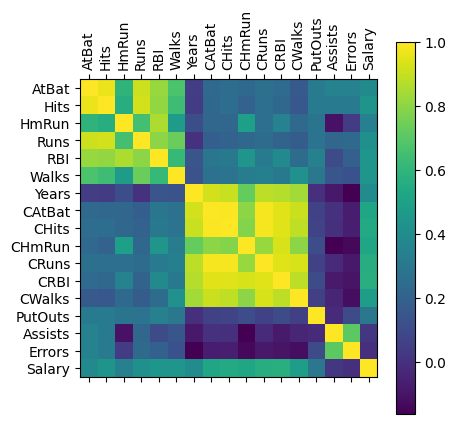

In [32]:
plt.matshow(hitter_data_corr)
plt.colorbar()
plt.xticks(range(len(hitter_data_corr.index)), hitter_data_corr.index, rotation=90)
plt.yticks(range(len(hitter_data_corr.index)), hitter_data_corr.index)

In [33]:
# This correlation matrix shows the most correlated data columns in the whole data set. 
# From this matrix, we can see that the CHits and the CAtbat columns are very closely correlated so we can use those for the next tests.

Text(0, 0.5, 'Percent Accuracy')

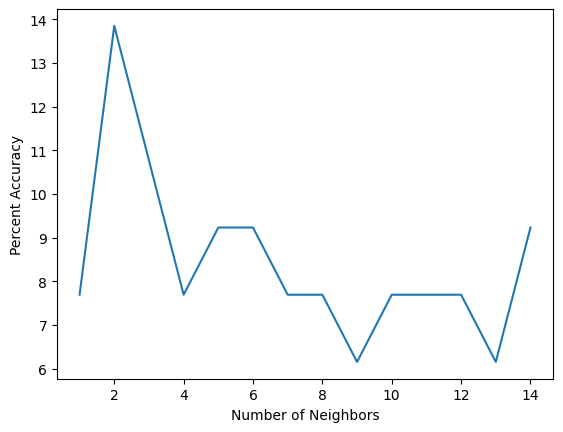

In [34]:
k_value = []
accuracies = []

# Iterate over the values of k we want to try
for k in range(1, 15, 1):
    # Define the classifier with the given number of neighbors
    classifier = KNeighborsClassifier(n_neighbors=k)
    # Fit the model with the training data
    classifier.fit(X_train, y_train)
    # Create the predictions
    predictions = classifier.predict(X_test)
    # Find the accuracy score
    accuracy = accuracy_score(y_test, predictions)
    # Save the data to the appropriate lists
    k_value.append(k)
    accuracies.append(accuracy*100)

# Create a plot of accuracy versus the number of neighbors in the
# calculation
plt.plot(k_value, accuracies)
plt.xlabel("Number of Neighbors")
plt.ylabel("Percent Accuracy")

7.6923076923076925


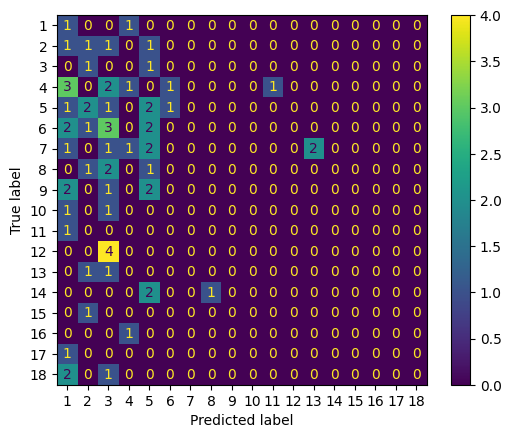

In [35]:
classifier = KNeighborsClassifier(n_neighbors=8)
classifier.fit(X_train, y_train)
predictions = classifier.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(accuracy*100)
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)

In [36]:
# graph

In [37]:
Hits_ = hitter_data["Hits"].value_counts()
Hits_

Hits
53     6
70     6
76     6
113    5
163    5
      ..
194    1
186    1
124    1
207    1
172    1
Name: count, Length: 144, dtype: int64

In [38]:
Years_ = hitter_data["Years"].value_counts()
Years_

Years
4     36
6     30
5     30
3     29
2     25
1     22
7     21
8     16
9     15
12    14
10    14
14    13
13    12
11    10
15     9
18     7
17     7
16     7
20     2
24     1
23     1
19     1
Name: count, dtype: int64

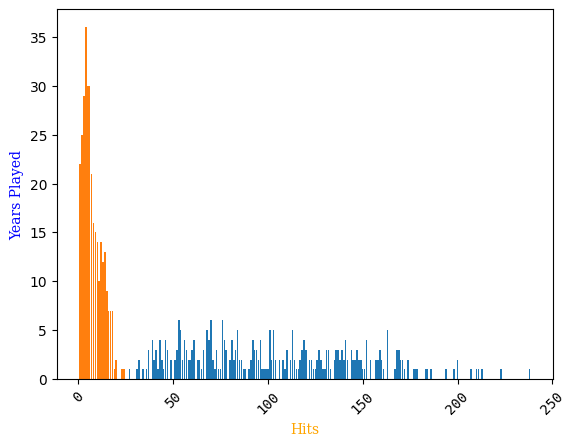

In [39]:
plt.bar(Hits_.index, Hits_)
plt.bar(Years_.index, Years_)
plt.xlabel("Hits", fontfamily="serif", c="orange")
plt.ylabel("Years Played", fontfamily="serif", c="blue")
plt.xticks(fontsize=10, fontfamily="monospace", rotation=45)
plt.show()  

In [40]:
corr = scipy.stats.pearsonr(hits, years)
print(corr)

correlation_score = corr[0]
print("The Correlation score is:", correlation_score)

PearsonRResult(statistic=np.float64(0.04476655694238094), pvalue=np.float64(0.42337218615922584))
The Correlation score is: 0.04476655694238094
